In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import os
os.chdir('/Users/ryotarohiraki/Desktop/Spring 2026/Capstone/projects')

In [2]:
#retrieve data
cps14 = pd.read_pickle('dataset/cleaned_dataset/cleaned_cps14_with_nearest_college.pkl')
# cps13 = pd.read_pickle('dataset/cleaned_dataset/cleaned_cps13_with_nearest_college_imgfeat_pca.pkl')
# cps12 = pd.read_pickle('dataset/cleaned_dataset/cleaned_cps12_with_nearest_college_imgfeat_pca.pkl')

cps14.columns

Index(['person_num', 'log_wage', 'educ', 'exp', 'exp2', 'female', 'black',
       'mv', 'age', 'birth_place', 'employed', 'PUMA', 'STATE',
       'same_home_as_14ys', 'same_home_as_13ys', 'same_home_as_12ys', 'mover',
       'age_bins', 'pums_weight', 'nearest_college_unitid',
       'nearest_college_lon', 'nearest_college_lat',
       'nearest_college_dist_km'],
      dtype='object')

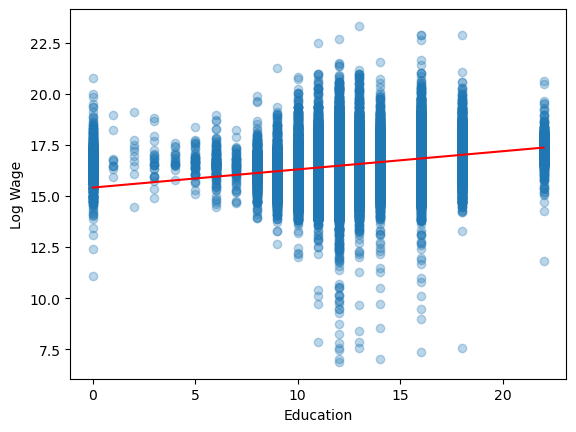

In [3]:
plt.scatter(cps14['educ'], cps14['log_wage'], alpha=0.3)

plt.xlabel('Education')
plt.ylabel('Log Wage')

#reg line
m, b = np.polyfit(cps14['educ'], cps14['log_wage'], 1)

x_line = np.linspace(cps14['educ'].min(), cps14['educ'].max(), 100)

plt.plot(x_line, m*x_line + b, color="red")

plt.show()

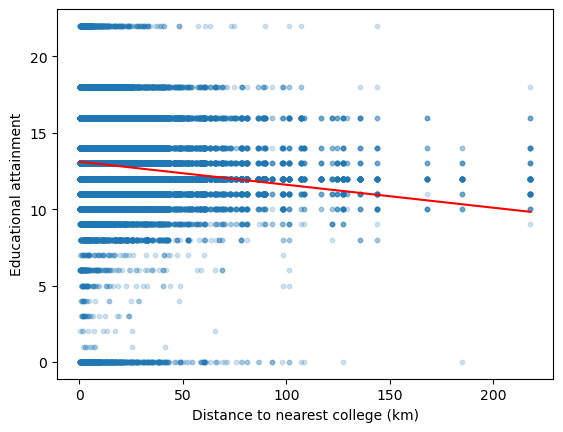

In [4]:
df = cps14.copy()

tmp = df[["nearest_college_dist_km", "educ"]].copy()
tmp = tmp.replace([np.inf, -np.inf], np.nan).dropna()

x = tmp["nearest_college_dist_km"].to_numpy()
y = tmp["educ"].to_numpy()

plt.scatter(x, y, alpha=0.2, s=10)

plt.xlabel("Distance to nearest college (km)")
plt.ylabel("Educational attainment")

# 回帰線
m, b = np.polyfit(x, y, 1)

x_line = np.linspace(x.min(), x.max(), 100)
plt.plot(x_line, m * x_line + b, color="red")

plt.show()

/var/folders/hh/zj6wtrxj153_fsvfp4061kgr0000gn/T/ipykernel_18109/376846456.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  binned = tmp.groupby("bin").agg({


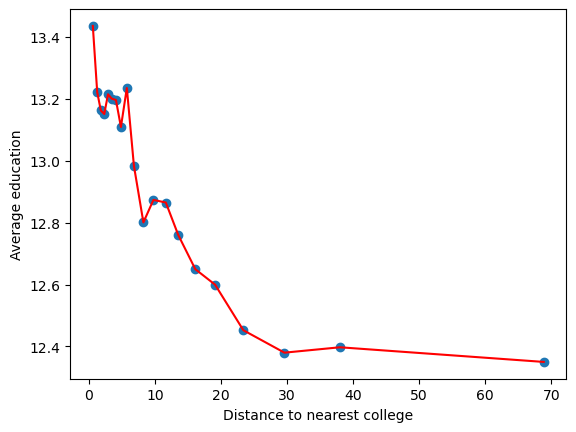

In [5]:
tmp["bin"] = pd.qcut(tmp["nearest_college_dist_km"], 20)

binned = tmp.groupby("bin").agg({
    "nearest_college_dist_km": "mean",
    "educ": "mean"
}).reset_index()

plt.scatter(binned["nearest_college_dist_km"], binned["educ"])
plt.plot(binned["nearest_college_dist_km"], binned["educ"], color="red")
plt.xlabel("Distance to nearest college")
plt.ylabel("Average education")
plt.show()

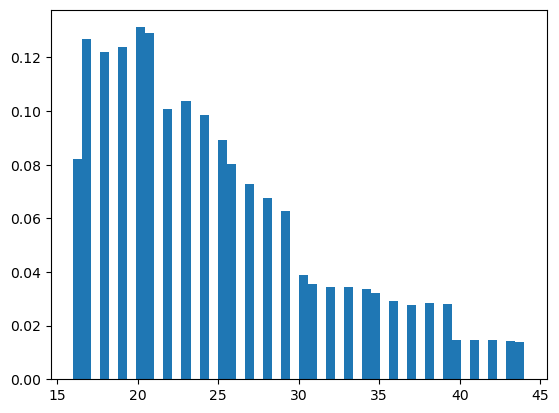

In [6]:

plt.hist(cps14["age"], bins = 50, density=True)
plt.show()